**<center>3F2 Lab Report<center>**

Name: Yang
Surname: Cao
CrsId: yc620
Apparatus #: Track 2

In [1]:
import numpy as np
import scipy.interpolate
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = [16, 8]

In [2]:
# Define the  physical constants for the pendulum experiment

g=9.81  # m/s^2
L=0.125 # distance from pendulum's centre of mass to pivot in m
a=0.016 # radius of pulley in m
m=0.32  # mass of pendulum in kg
M=0.7  # mass of carriage in kg
I=8e-5  # moment of inertia on motor shaft in kg m^2
km = 0.08  # torque motor constant in Nm/A
ka = -0.50 # amplifier constant in A/V

gamma =  M/m + I/(m*np.power(a,2))

#scale factors to get physical units metres radians and seconds.
#in the crane/down position
# [x xdot Ltheta Lthetadot]=[CP CV PP PV]*Sc where,
Sc=np.diag([-1/12.5, -1/2.23, L/3.18, L/0.64])

# in the inverted position
# [x xdot Lphi Lphidot]=[CP CV PP PV]*Sp where,
Sp=np.diag([-1/12.5, -1/2.23, L/3.18, -L/0.64])

#controller amplifier gains on each measurement
opamp_c = np.diag([-20,-30, 20, -10]) # for crane controller
opamp_p = np.diag([10,20,30,-20]) # for inverted pendulum controller

#maximum torque from the motor in Nm
Tmax=0.4

# squares of the natural frequencies
om12=g/L 
om02=om12*(1+1/gamma)

#linearized crane  model

Ac=np.array([[0, 1, 0, 0,], [0, 0, om12-om02, 0], [0, 0, 0, 1], [0, 0, -om02, 0]])
Cc=-(ka*km/(m*a*gamma))*np.linalg.solve(Sc,opamp_c)
B=np.array([[0],[1],[0],[1]])

#linearized inverted pendulum model
Ap=np.array([[0, 1, 0, 0], [0, 0, om02-om12, 0], [0, 0, 0, 1], [0, 0, om02, 0]])
Cp=-(ka*km/(m*a*gamma))*np.linalg.solve(Sp,opamp_p)

# Sampling period 
h=0.0025 #sampling period
h_sim=0.002 #simulation step size

Helper functions are defined here (you should not have to change these). Click to reveal and then click the vertical bar to rehide.

In [3]:
# Define helper functions

def solver_crane(x0,tsim,tdem,xdem,p):
  x = np.copy(x0)
  x_sim = x.reshape(1,4)
  T_sim = []
  if x0[2]>0.05:
      stopped=0
  else:
      stopped =1
    
  def next_state_crane(x):
    theta = x[2]/L
    sinth = np.sin(theta)
    costh = np.cos(theta)
    newx = np.empty(4) 
    nonlocal stopped
    if stopped==1 and (np.abs(T/a - m*g*sinth*costh - m/L*sinth*x[3]**2)< Fstatic):
        newx[0] = x[0]
        newx[1] = 0.0
        newx[2] = x[2]+ h_sim*x[3]+0.5*h_sim**2*(-g*sinth)
        sinth1 = np.sin(newx[2]/L)
        costh1 = np.cos(newx[2]/L)
        newx[3] = x[3] -h_sim*g*(sinth+sinth1)*0.5
    else:
         stopped=0
         x24dot =np.linalg.solve(np.array([[1+gamma,-costh],[-costh,1]]),np.array([-sinth/L*x[3]**2 + T/(m*a)-(F/m)*np.sign(x[1]),-g*sinth]))    
         newx[[0,2]]=x[[0,2]]+h_sim*x[[1,3]]+0.5*(h_sim**2)*x24dot

         sinth1 = np.sin(newx[2]/L)
         costh1 = np.cos(newx[2]/L)
         x24dot1 = np.linalg.solve(np.array([[1+gamma,-costh1],[-costh1,1]]),np.array([-sinth1/L*x[3]**2 + T/(m*a)-(F/m)*np.sign(x[1]),-g*sinth1]))    
         newx[[1,3]]=x[[1,3]]+h_sim*0.5*(x24dot+x24dot1)
         if((x[1]!=0.0) & (x[1]*newx[1]<=0.0)):
             stopped= 1
    return newx

  for t in tsim:
      xd = np.interp(t,tdem,xdem)
      T= (ka*km*P@ opamp_c@ np.linalg.solve(Sc,(x-np.array([xd,0,0,0]))))[0]
      if np.abs(T)>Tmax:
          T= Tmax*np.sign(T)
      T_sim.append(T.item())
      x = next_state_crane(x)
      x_sim = np.vstack((x_sim,np.transpose(x)))
  return x_sim
# Define helper functions

def solver_pendulum(x0,tsim,tdem,xdem,p):
  x = np.copy(x0)
  x_sim = x.reshape(1,4)
  T_sim = []
  if x0[2]>0.05:
      stopped=0
  else:
      stopped =1

  def next_state_pendulum(x):
    phi = x[2]/L
    sinphi = np.sin(phi)
    cosphi = np.cos(phi)
    newx = np.empty(4) 
    nonlocal stopped
    if stopped==1 and (np.abs(T/a + m*g*sinphi*cosphi - m/L*sinphi*newx[3]**2)< Fstatic): #x[3]
        newx[0] = x[0]
        newx[1] = 0.0
        newx[2] = x[2]+ h_sim*x[3]+0.5*h_sim**2*(g*sinphi)
        sinphi1 = np.sin(newx[2]/L)
        cosphi1 = np.cos(newx[2]/L)
        newx[3] = x[3] +h_sim*g*(sinphi+sinphi1)*0.5
    else:
         stopped=0
         x24dot =np.linalg.solve(np.array([[1+gamma,-cosphi],[cosphi,-1]]),np.array([-sinphi/L*x[3]**2 + T/(m*a)-(F/m)*np.sign(x[1]),-g*sinphi]))    
         newx[[0,2]]=x[[0,2]]+h_sim*x[[1,3]]+0.5*(h_sim**2)*x24dot

         sinphi1 = np.sin(newx[2]/L)
         cosphi1 = np.cos(newx[2]/L)
         x24dot1 = np.linalg.solve(np.array([[1+gamma,-cosphi1],[cosphi1,-1]]),np.array([-sinphi1/L*x[3]**2 + T/(m*a)-(F/m)*np.sign(x[1]),-g*sinphi1]))    
         newx[[1,3]]=x[[1,3]]+h_sim*0.5*(x24dot+x24dot1)
         if((x[1]!=0.0) & (x[1]*newx[1]<=0.0)):
             stopped= 1
    return newx

  for t in tsim:
      xd = np.interp(t,tdem,xdem)
      T= (ka*km*P@ opamp_p@ np.linalg.solve(Sp,(x-np.array([xd,0,0,0]))))[0]
      if np.abs(T)>Tmax:
          T= Tmax*np.sign(T)
      T_sim.append(T.item())
      x = next_state_pendulum(x)
      x_sim = np.vstack((x_sim,np.transpose(x)))
  return x_sim

def loadlogdata(n,ScaleF):

  if n> 9:
    filename = 'Plot 0' + str(n) + '.csv'
  else:
    filename = 'Plot 00' + str(n)+ '.csv'

  LoadedDataCSV = np.genfromtxt(filename,delimiter=',',skip_header=16)
  # this seems to be sufficient if the offset for the header is always the same
  #print(LoadedDataCSV)
  #LoadedDataCSV = np.delete(LoadedDataCSV,-1,axis=1)
  #print(LoadedDataCSV)
  DataOfInterestCSV = np.array(LoadedDataCSV[:,[2,3,4,5,1]])
  # we now need to swap data so to place it in the following order
  # t CP CV PP PV CD
  # from an orginal order of: 
  # t CD CP CV PP PV
  logdataCSV = DataOfInterestCSV*20/4095-10
  logdataCSV[:,[1,2,3]] = -logdataCSV[:,[1,2,3]]
  xdata=np.concatenate([logdataCSV[:,0:4]@ScaleF, logdataCSV[:,-1:]*ScaleF[0,0]], axis=1)
  ###  
  xdem = xdata[:,-1]
  endtime=LoadedDataCSV[-1,0]
  t = np.linspace(0,endtime,xdata.shape[0])

  return xdata, xdem, t
 
def plot_function_crane(t0,tf,t,xdata,tsim,x_sim,p):
  ind = (t>=t0) & (t<=tf)
  plt.figure()
  plt.suptitle("Crane position with p = %s"%p, fontsize=15)

  plt.subplot(411)
  plt.plot(t[ind],xdata[ind,0], color='blue') #data
  plt.plot(tsim,x_sim[:-1,0], color='red',linestyle='--') #simulation
  plt.plot(t[ind],xdata[ind,-1], linestyle =':', color='green') # Demand
  plt.legend(['Measured','Simulated','Demand']);
  plt.ylabel("x[m]")

  plt.subplot(412)
  plt.plot(t[ind],xdata[ind,1], color='blue') #data
  plt.plot(tsim,x_sim[:-1,1], color='red',linestyle='--') #simulation
  plt.legend(['Measured','Simulated']); 
  plt.ylabel("v[m/s]")

  plt.subplot(413)
  plt.plot(t[ind],xdata[ind,2], color='blue') #data
  plt.plot(tsim,x_sim[:-1,2], color='red',linestyle='--') #simulation
  plt.legend(['Measured','Simulated']);
  plt.ylabel("L$\Theta$[m]")

  plt.subplot(414)
  plt.plot(t[ind],xdata[ind,3], color='blue') #data
  plt.plot(tsim,x_sim[:-1,3], color='red',linestyle='--') #simulation
  plt.legend(['Measured','Simulated']);
  plt.ylabel("L$\omega$[m/s]")

  plt.xlabel("time [s]")

def plot_function_pendulum(t0,tf,t,xdata,tsim,x_sim,p):
  ind = (t>=t0) & (t<=tf)
  plt.figure()
  plt.suptitle("Pendulum position with p = %s"%p, fontsize=15)

  plt.subplot(411)
  plt.plot(t[ind],xdata[ind,0], color='blue') #data
  plt.plot(tsim,x_sim[:-1,0], color='red',linestyle='--') #simulation
  plt.plot(t[ind],xdata[ind,-1], linestyle =':', color='green') # Demand
  plt.legend(['Measured','Simulated','Demand']);
  plt.ylabel("x[m]")

  plt.subplot(412)
  plt.plot(t[ind],xdata[ind,1], color='blue') #data
  plt.plot(tsim,x_sim[:-1,1], color='red',linestyle='--') #simulation
  plt.legend(['Measured','Simulated']); 
  plt.ylabel("v[m/s]")

  plt.subplot(413)
  plt.plot(t[ind],xdata[ind,2], color='blue') #data
  plt.plot(tsim,x_sim[:-1,2], color='red',linestyle='--') #simulation
  plt.legend(['Measured','Simulated']);
  plt.ylabel("L$\Theta$[m]")

  plt.subplot(414)
  plt.plot(t[ind],xdata[ind,3], color='blue') #data
  plt.plot(tsim,x_sim[:-1,3], color='red',linestyle='--') #simulation
  plt.legend(['Measured','Simulated']);
  plt.ylabel("L$\omega$[m/s]")

  plt.xlabel("time [s]")

<>:143: SyntaxWarning: invalid escape sequence '\T'
<>:149: SyntaxWarning: invalid escape sequence '\o'
<>:175: SyntaxWarning: invalid escape sequence '\T'
<>:181: SyntaxWarning: invalid escape sequence '\o'
/tmp/xpython_42/4036594307.py:143: SyntaxWarning: invalid escape sequence '\T'
  plt.ylabel("L$\Theta$[m]")
/tmp/xpython_42/4036594307.py:149: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("L$\omega$[m/s]")
/tmp/xpython_42/4036594307.py:175: SyntaxWarning: invalid escape sequence '\T'
  plt.ylabel("L$\Theta$[m]")
/tmp/xpython_42/4036594307.py:181: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel("L$\omega$[m/s]")


# 3) Crane mode

## 3.1) Friction measurement
Measure the dynamic and static friction

In [4]:
F = 0.4
Fstatic = 0.8

## 3.3) Synthesis of the $p_3$ and $p_4$ controllers


In [5]:
P = np.array([[0.35,0.15,0.20,0.15]]);
print(np.linalg.eig(Ac-B@P@Cc)[0]) # Note that the [0] is there to ignore the second output of eig

[-1.14376589+23.00560226j -1.14376589-23.00560226j
 -1.76364152 +5.37094578j -1.76364152 -5.37094578j]


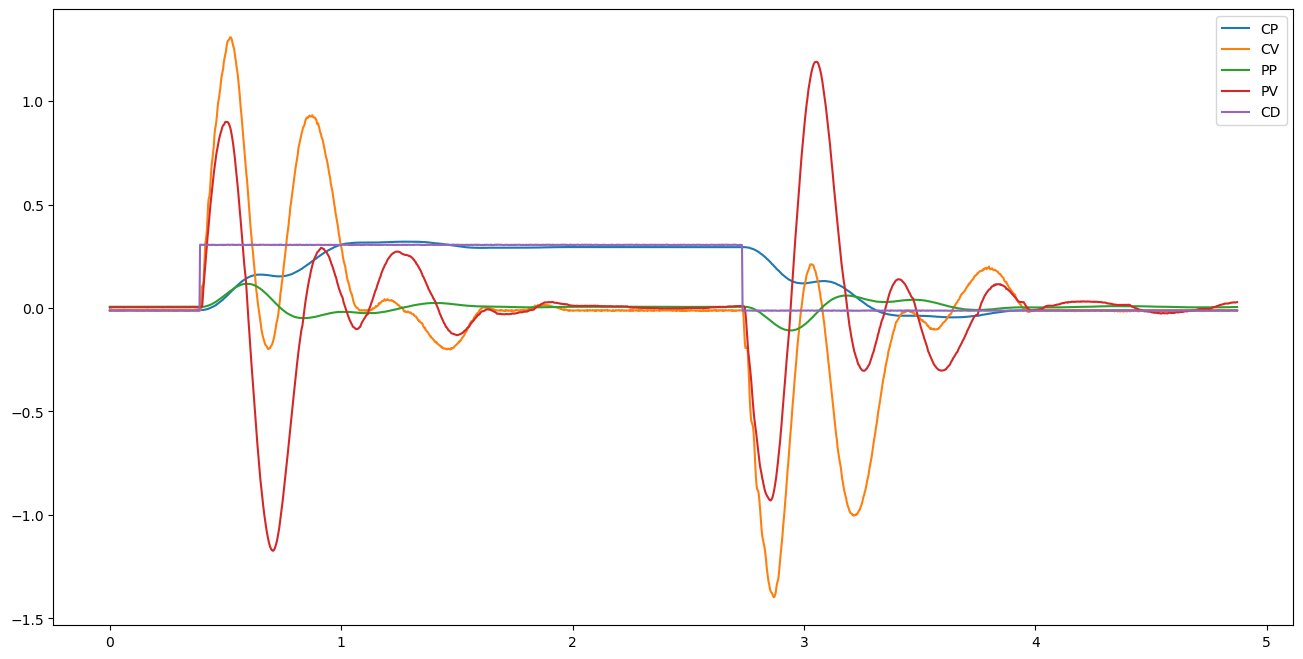

In [6]:
############################## LOAD DATA  #######################################

xdata, xdem, tdata = loadlogdata(16, Sc)
# in the previous line xdem is the external input into the system.
plt.plot(tdata,xdata)
plt.legend(['CP','CV','PP','PV','CD']);

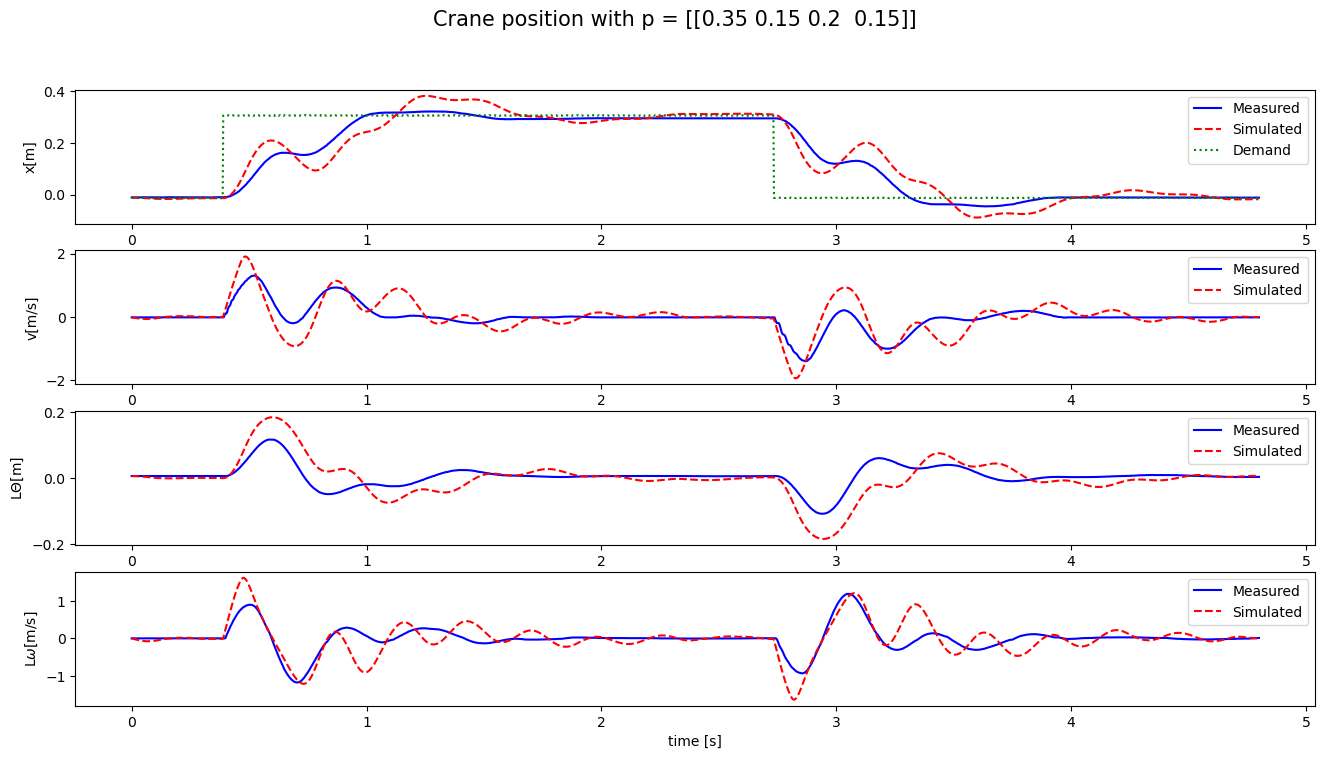

In [7]:
t0 = 0; tf = 4.8 # define the simlation time to be considered

# Set up the initial conditions and time index for the simulation, this uses the recorded data

tsim = np.arange(t0,tf,h_sim)
x0=scipy.interpolate.interp1d(tdata,xdata[:,:4].T)(t0)

x_sim = solver_crane(x0,tsim,tdata,xdem,P)

plot_function_crane(t0,tf,tdata,xdata,tsim,x_sim,P)

# Comment on the transient response and pole position

The transient response of the crane quickly attenuates under the setting (p1, p2, p3, p4) = (0.35, 0.15, 0.20, 0.15). The pole positions are on the left of the imaginary axis, the first pair arises mostly likely from the sudden jolt when the device experiences a step change. This first pair dies off quickly (time ~0.1s) and has a high oscillating frequency. The second pair has a much slower frequency, acting almost like a constant error term that slowly decays as the device moves (time ~1s).

## 3.4) Pole-placement

### 3.4a)  
Use example 1 of section A.5 together with the scale factors of section A.7 to place all the closed-loop poles at $−\omega_1 = −\sqrt 78.5$. Record your calculated values of $p_1–p_4$

In [8]:
P = np.array([[0.13,0.21,0.23,0.0]])
print("P:", P)
print(np.linalg.eig(Ac-B@P@Cc)[0]) 
# Note that the [0] is there to ignore the second output of eig

P: [[0.13 0.21 0.23 0.  ]]
[-12.45360996+6.46216554j -12.45360996-6.46216554j
  -4.89083448+2.84116008j  -4.89083448-2.84116008j]


In [9]:
###VERIFICATION FOR ACTUAL POLES###

import numpy as np

# Define your real pole magnitudes
alpha = 8.86
beta = 8.86
omega = 8.86

# Desired characteristic polynomial coefficients for (s+a)(s+b)(s+w)^2
# s^4 + c3*s^3 + c2*s^2 + c1*s + c0
c3 = alpha + beta + 2*omega
c2 = 2*omega*(alpha + beta) + alpha*beta + omega**2
c1 = 2*omega*alpha*beta + omega**2*(alpha + beta)
c0 = alpha * beta * omega**2

# Solve for k gains based on your system's specific Ac and B matrices
# Note: These assignments depend on the structure of your original plant (om02, om12, etc.)
k = np.empty(4)
k[0] = c0 / om12
k[1] = c1 / om12
k[2] = c2 - om02 - k[0] # This logic assumes your previous plant structure
k[3] = c3 - k[1]        # Adjust based on your specific state-space model

# Calculate Potentiometer settings
P = np.array([k / np.diag(Cc)])

print(f"Poles placed at: -{alpha}, -{beta}, -{omega}, -{omega}")
print("P = ", P)

# Verification
# Ensure Ac, B, and Cc are defined in your workspace before running this
# print(np.linalg.eig(Ac - B @ P @ Cc)[0])

Poles placed at: -8.86, -8.86, -8.86, -8.86
P =  [[1.27201112e-01 2.14600667e-01 2.30196364e-01 7.00125430e-05]]


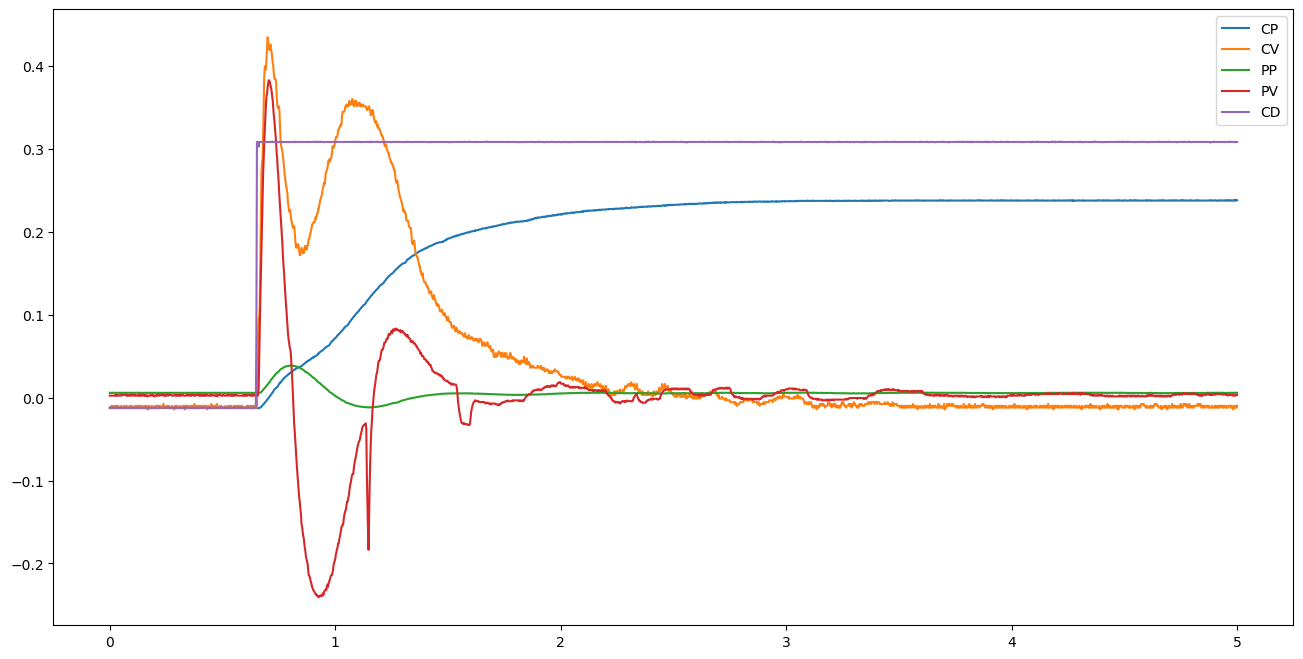

In [10]:
############################## LOAD DATA #######################################
xdata, xdem, tdata =loadlogdata(13,Sc)
# in the previous line xdem is the external input into the system.

plt.plot(tdata,xdata)
plt.legend(['CP','CV','PP','PV','CD']);

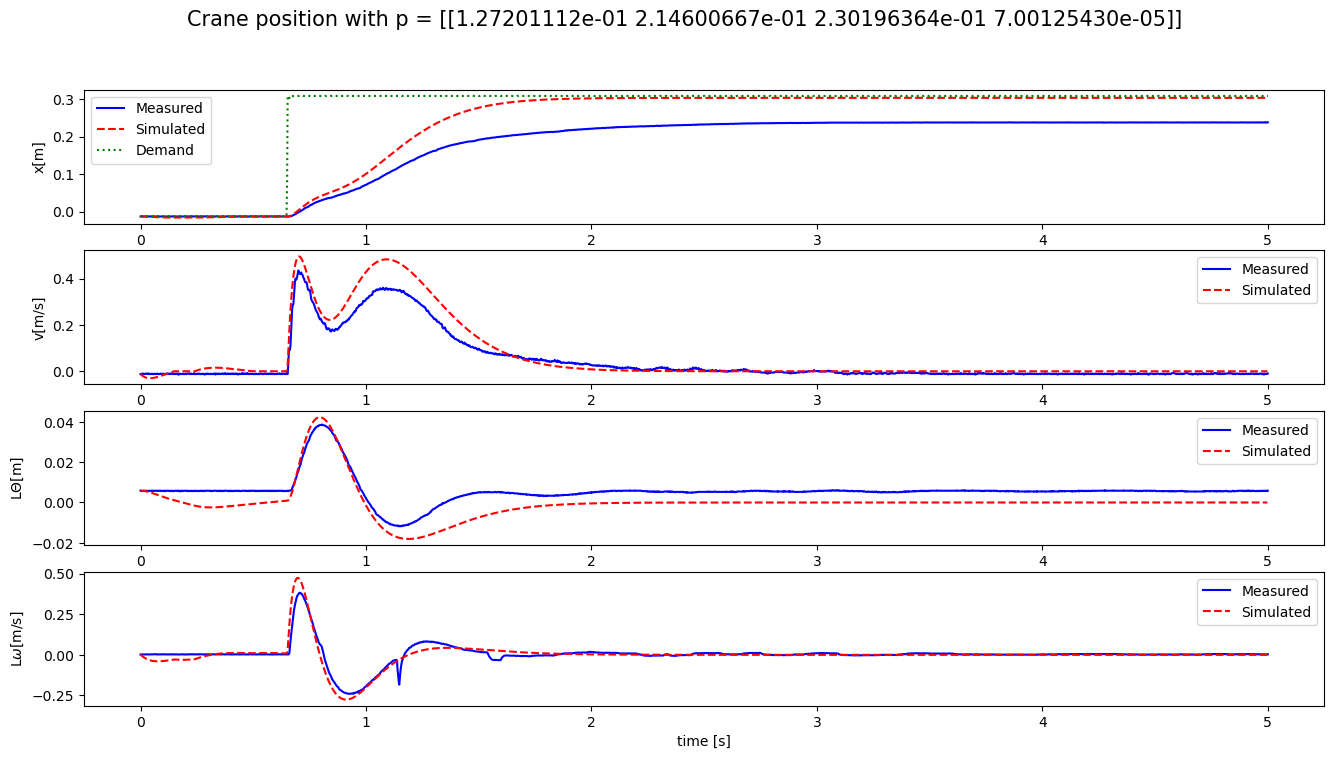

In [11]:
t0 = 0; tf = 5 # define the simlation time to be considered

# Set up the initial conditions and time index for the simulation, this uses the recorded data

tsim = np.arange(t0,tf,h_sim)
x0=scipy.interpolate.interp1d(tdata,xdata[:,:4].T)(t0)

x_sim = solver_crane(x0,tsim,tdata,xdem,P)

plot_function_crane(t0,tf,tdata,xdata,tsim,x_sim,P)


# Comment on the consistency with the target pole position

The theoretical poles are roughly consistent with the measured results, as seen in the graph above. It should be noted that even when the exact results from the theoretical calculated values for (p1, p2, p3, p4) are entered into the poles calculator with over 7 digits of accuracy, the poles obtained are very far off from the desired results. In reality, the device is only accurate up to 2 digits.

### 3.4b)  
Now increase the speed of response by placing the closed-loop poles at $-\alpha,-\beta,-\omega\pm j\omega$ for suitable values of $\alpha, \beta$ and $\omega$. Record your choice (of $\alpha, \beta$ and $\omega$) and the corresponding potentiometer settings. Log the step response and comment. *[It is not expected that you will choose the same values as any other student!]*.

In [12]:
alpha = 10; beta = 10;omega = 10
k = np.empty(4)
k[0]=2*omega**2*alpha*beta/om12
k[1]=(2*omega**2*(alpha+beta)+2*omega*alpha*beta)/om12
k[2]=2*omega**2+2*omega*(alpha+beta)+alpha*beta-om02-k[0]
k[3]=2*omega+alpha+beta-k[1] 
P=np.array([k/np.diag(Cc)])
print("alpha=", alpha, "beta=", beta, "omega =",omega)
print("P= ",P)
print(np.linalg.eig(Ac-B@P@Cc)[0]) 



alpha= 10 beta= 10 omega = 10
P=  [[0.41284404 0.46282964 0.27212883 0.28834576]]
[-10.+1.00000000e+01j -10.-1.00000000e+01j -10.+8.98453323e-07j
 -10.-8.98453323e-07j]


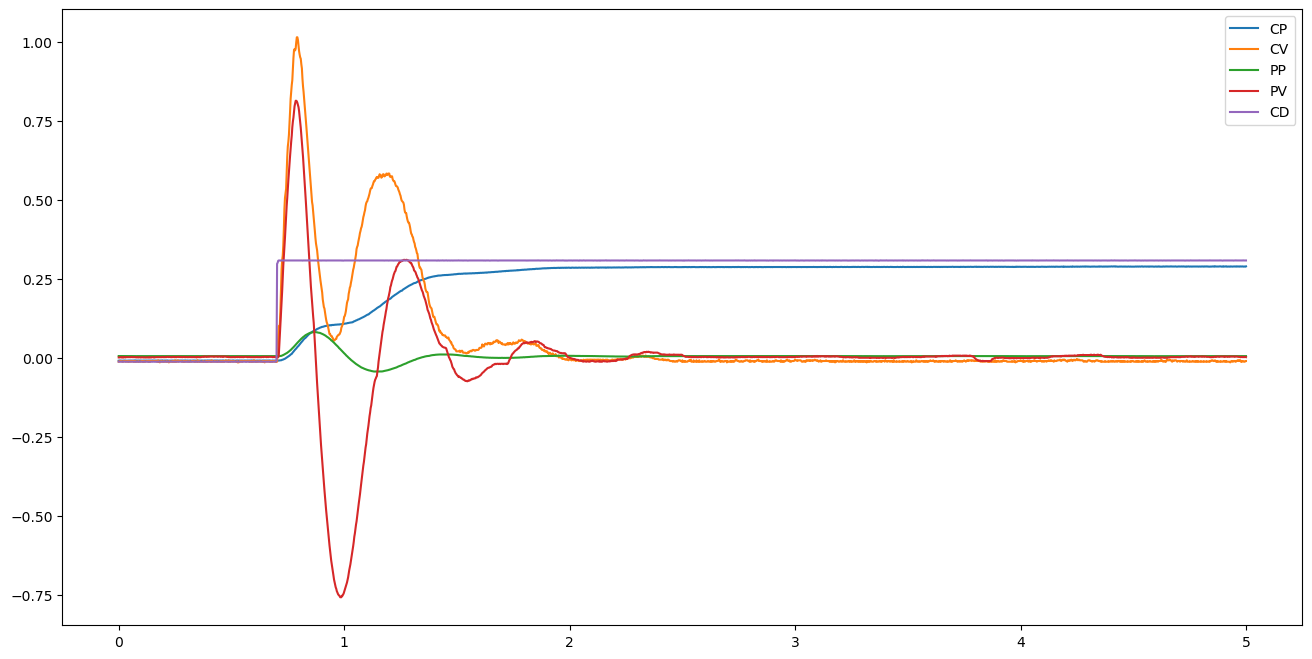

In [13]:
############################## LOAD DATA #######################################
xdata, xdem, tdata =loadlogdata(14,Sc)
# in the previous line xdem is the external input into the system.

plt.plot(tdata,xdata)
plt.legend(['CP','CV','PP','PV','CD']);

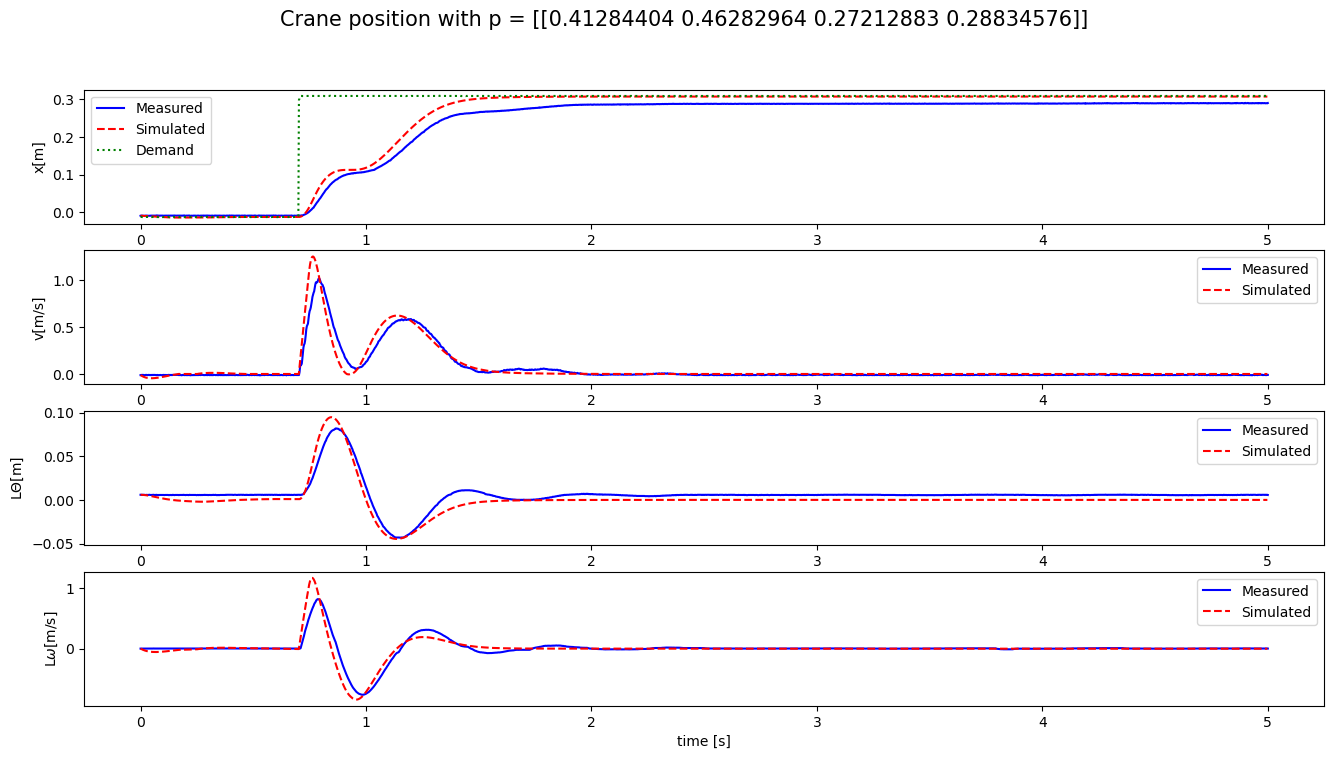

In [14]:
t0 = 0; tf = 5 # define the simlation time to be considered

# Set up the initial conditions and time index for the simulation, this uses the recorded data

tsim = np.arange(t0,tf,h_sim)
x0=scipy.interpolate.interp1d(tdata,xdata[:,:4].T)(t0)

x_sim = solver_crane(x0,tsim,tdata,xdem,P)

plot_function_crane(t0,tf,tdata,xdata,tsim,x_sim,P)


# Comment here on the response

After increasing the decaying factor of alpha and beta to 10 from 8.86, it can be seen from the graph above that the response of the crane enters steady state much faster. By increasing the frequency factor omega, it seems like the steady state error of system is reduced as well. The potentiometer is set to be 3.5V.

## 3.5) Variation of $p_2$
With the design 3.4(b) vary $p_2$ until instability just occurs. Log the step response just prior to the onset of oscillations, and record the value of $p_2$. Use the linear model in appendix A to predict the gain $k_2$ at which oscillation will occur, and predict the resonant frequency $\hat \omega$ see section A.5). Compare these with your experimental results (note: $k_2$ = 165 $p_2$ — see A.7(a))

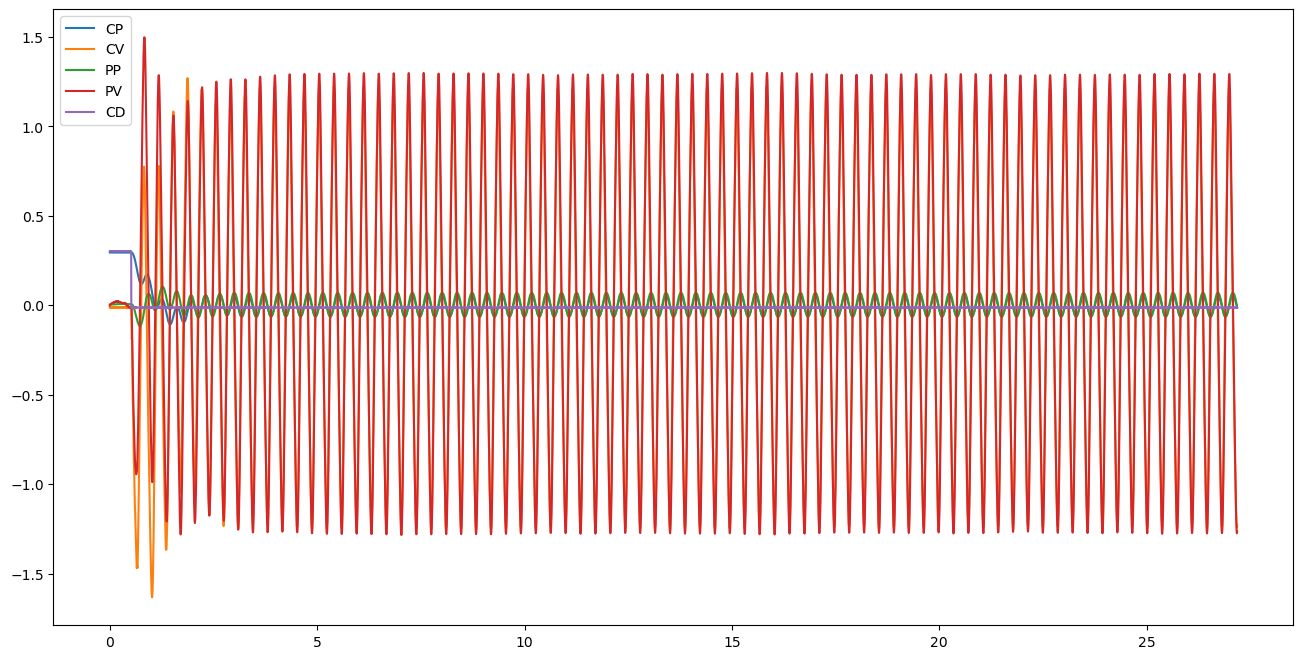

In [15]:
############################## LOAD DATA  #######################################

xdata, xdem, tdata = loadlogdata(19,Sc)
# in the previous line xdem is the external input into the system.

plt.plot(tdata,xdata)
plt.legend(['CP','CV','PP', 'PV', 'CD']);

In [16]:
P = np.array([[0.41,0.19,0.27,0.29]])
print("P:", P)
print(np.linalg.eig(Ac-B@P@Cc)[0]) 


P: [[0.41 0.19 0.27 0.29]]
[ 4.57476482+26.11156105j  4.57476482-26.11156105j
 -1.93649322 +4.95114934j -1.93649322 -4.95114934j]


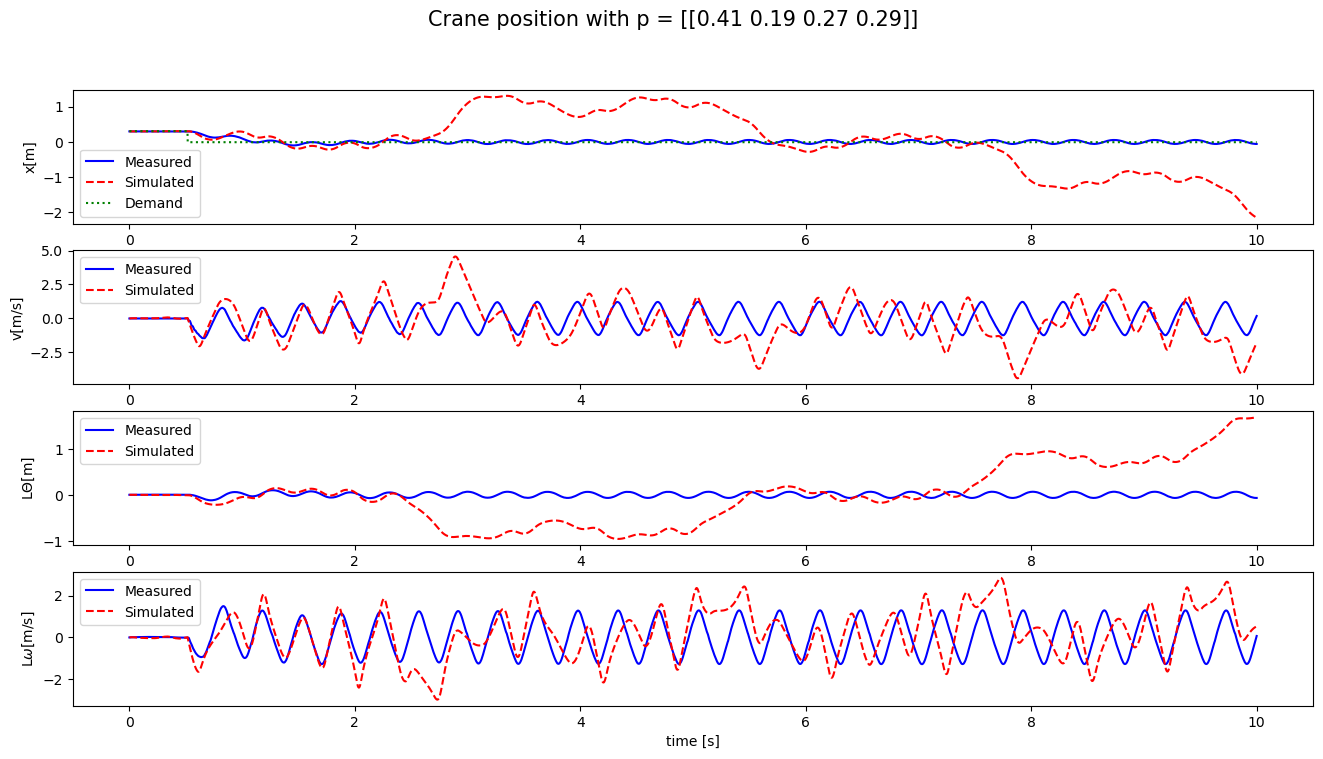

In [17]:
t0 = 0; tf = 10# define the simlation time to be considered

# Set up the initial conditions and time index for the simulation, this uses the recorded data

tsim = np.arange(t0,tf,h_sim)
x0=scipy.interpolate.interp1d(tdata,xdata[:,:4].T)(t0)

x_sim = solver_crane(x0,tsim,tdata,xdem,P)

plot_function_crane(t0,tf,tdata,xdata,tsim,x_sim,P)

 # Comment and discuss here section 3.5)
 Value of $p_2$ at the onset of the oscillations: 0.20, completely unstable at $p_2$ = 0.19
 Predicated gain $k_2$: 33
 Predicted frequency $\hat \omega$: 25.2 (In calculations, k4 > k2, so the frequency turns out to be a complex number. It was decided to take the magnitude of the frequency instead, since close to instability, values for k2 and k4 have similar magnitudes).
 
 Compare with actual gain and experimental results: From the graph, the frequency omega is about 17.3 rad/s. However, since the system is not settling down, this can be treated as in marginal stability, where the gain k2 is approximately zero.




# 4) Pendulum mode

## 4.2) No carriage feedback
Set $p_1 = p_2 = 0$ and $p_3$ and $p_4$ to stabilize the pendulum dynamics, say $p_3 = 0.500$ and $p_4 = 0.110$.  Now hold the pendulum upright and press RESET.  Manually note the force, on the pendulum, required to move the carriage - TAKE DUE CARE. Let go of the pendulum and explain the subsequent behaviour.

In [18]:
P = np.array([[0.0, 0.0, 0.5, 0.11]])
print("P:", P)
print(np.linalg.eig(Ap-B@P@Cp)[0]) 
# Note that the [0] is there to ignore the second output of eig

P: [[0.   0.   0.5  0.11]]
[  0.         +0.j           0.         +0.j
 -13.90617284+25.40781422j -13.90617284-25.40781422j]


 # Comment and disucss here section 4.2)


 Without carriage feedback, the carriage will move in the direction where the pendulum falls. Since the track has finite length, the carriage will hit onto either side of the track.

## 4.3) Pole placement
Using example 2 in section A.5 and the data in section A.7 calculate $p_i$ to place the closed-loop poles at $-\omega_1=-\sqrt{78.5}$, and record your calculated values. Log the response.

In [19]:
P = np.array([[0.25, 0.32, 0.35, 0.28]])
print("P:", P)
print(np.linalg.eig(Ap-B@P@Cp)[0]) 
# Note that the [0] is there to ignore the second output of eig

P: [[0.25 0.32 0.35 0.28]]
[-12.33849698+4.90693357j -12.33849698-4.90693357j
  -5.4392808 +2.18151943j  -5.4392808 -2.18151943j]


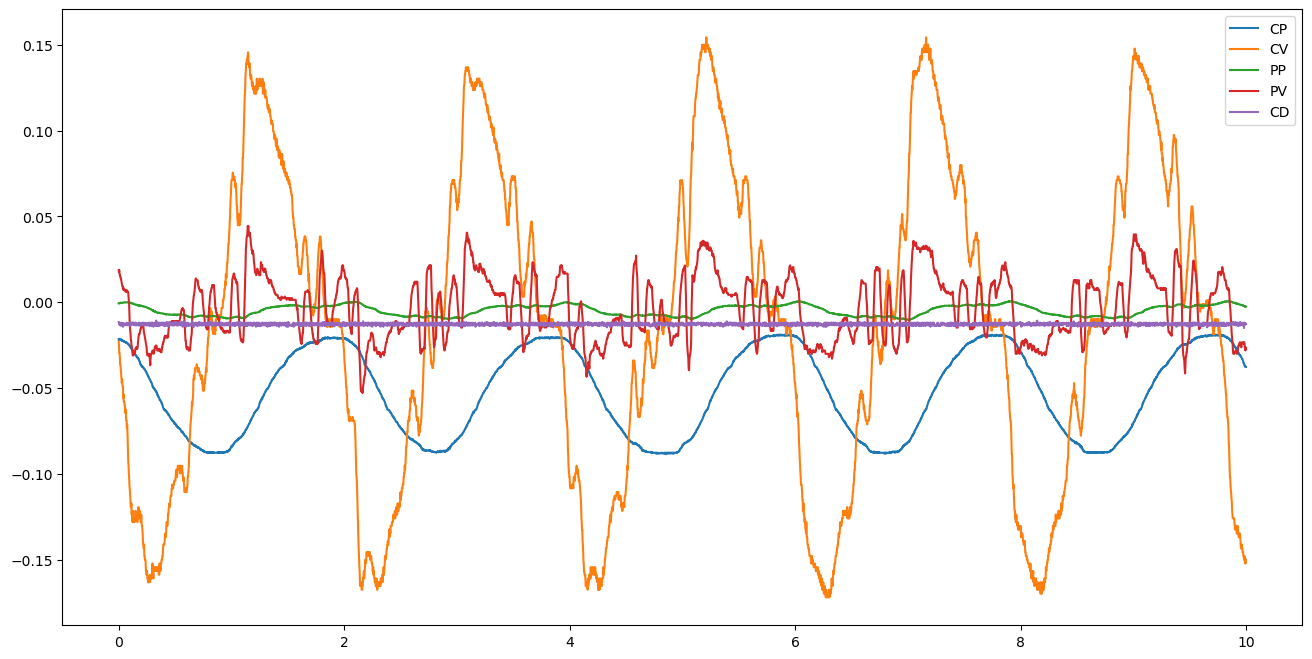

In [20]:
############################## LOAD DATA  #######################################

xdata, xdem, tdata = loadlogdata(20,Sp)
# in the previous line xdem is the external input into the system.

plt.plot(tdata,xdata)
plt.legend(['CP','CV','PP','PV','CD']);

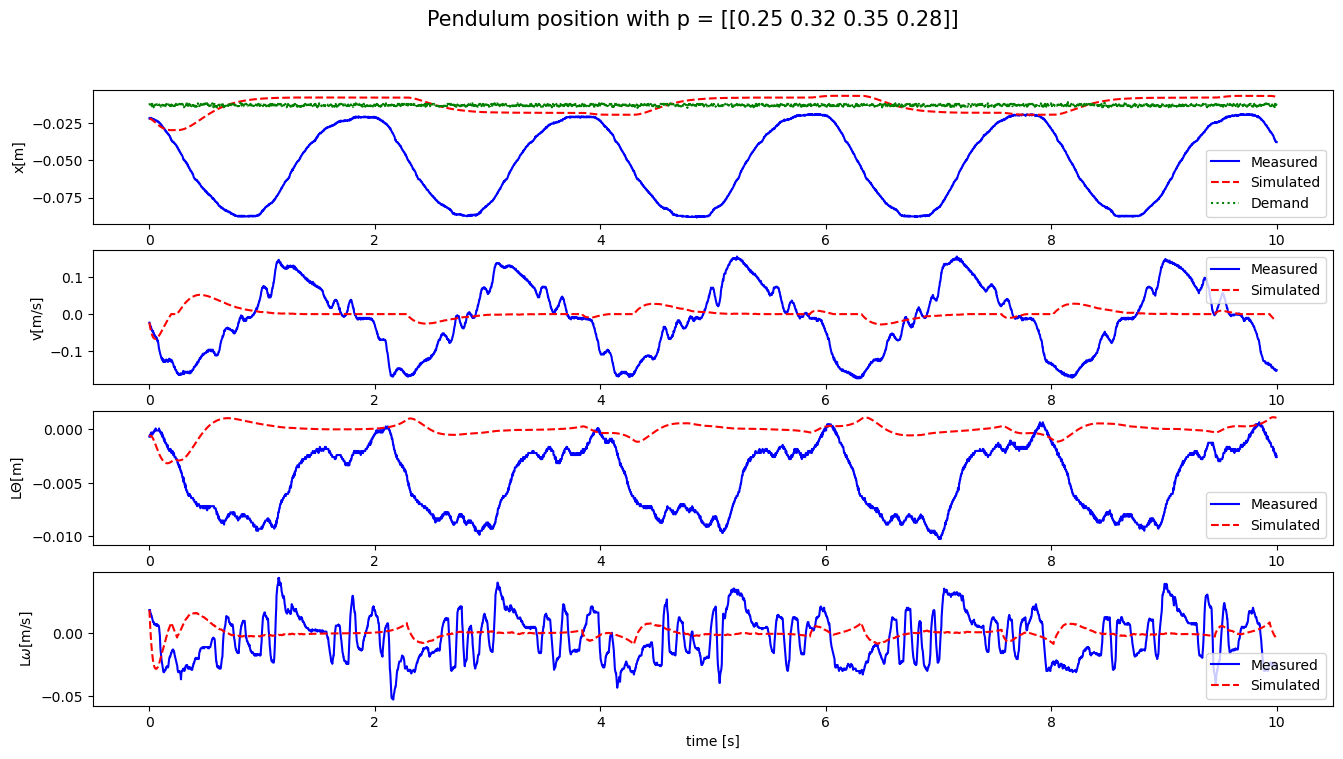

In [21]:
t0 = 0; tf = 10 # define the simlation time to be considered

# Set up the initial conditions and time index for the simulation, this uses the recorded data

tsim = np.arange(t0,tf,h_sim)
x0=scipy.interpolate.interp1d(tdata,xdata[:,:4].T)(t0)

x_sim = solver_pendulum(x0,tsim,tdata,xdem,P)

plot_function_pendulum(t0,tf,tdata,xdata,tsim,x_sim,P)


## 4.4) Limit Cycles
Set the potentiometers to $p_1 = 0.23 \ \ p_2 = 0.50 \ \ p_3 = 0.63 \ \ p_4 = 0.40$ which should give a reasonably stable response. Now reduce $p_2$ until large oscillations occur (i.e. the carriage nearly hits the end stops). Record your value of $p_2$, and log the response.  Now increase $p_2$ until the system is almost unstable. Record your value of $p_2$, and log the response to a small step.

In [22]:
P = np.array([[0.23, 0.50, 0.63, 0.40]])
print("P:", P)
print(np.linalg.eig(Ap-B@P@Cp)[0]) 
# Note that the [0] is there to ignore the second output of eig

P: [[0.23 0.5  0.63 0.4 ]]
[-20.51101586+19.4423977j  -20.51101586-19.4423977j
  -2.52602118 +0.77095105j  -2.52602118 -0.77095105j]


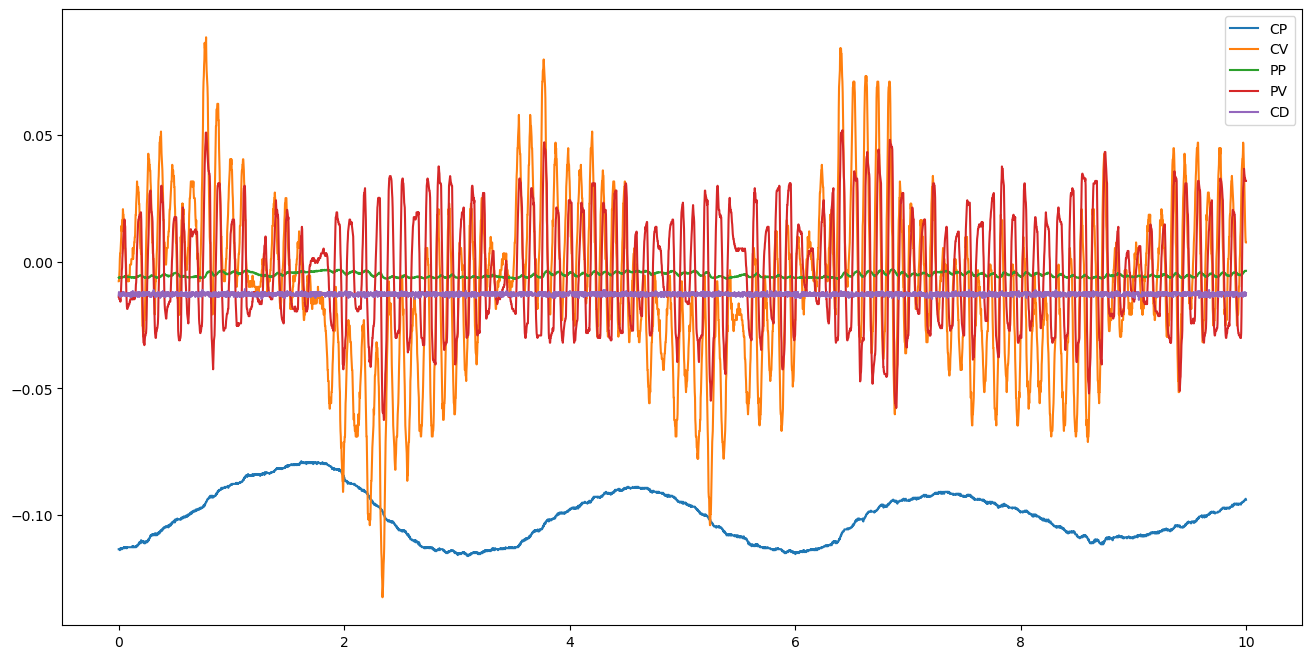

In [23]:
############################## LOAD DATA  #######################################

xdata, xdem, tdata = loadlogdata(21,Sp)
# in the previous line xdem is the external input into the system.

plt.plot(tdata,xdata)
plt.legend(['CP','CV','PP','PV','CD']);

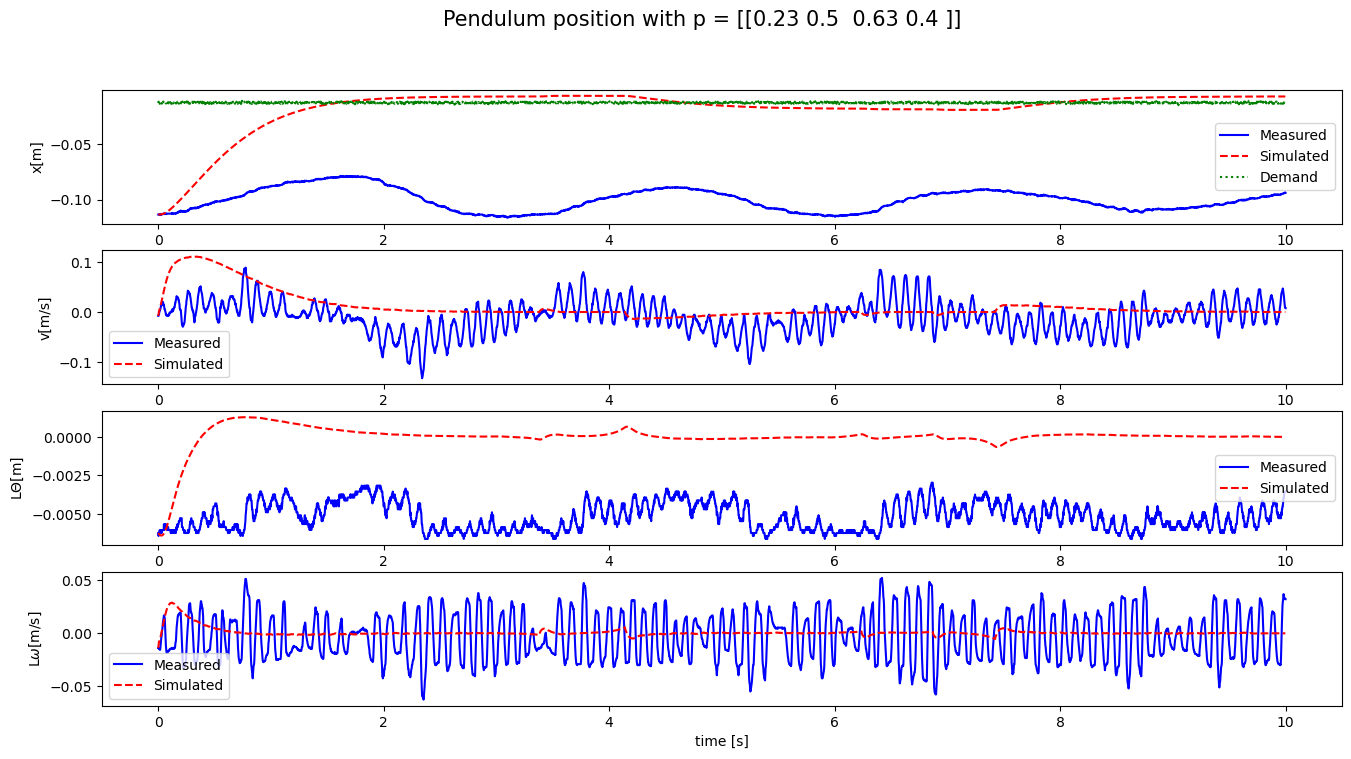

In [24]:
t0 = 0; tf = 10 # define the simlation time to be considered

# Set up the initial conditions and time index for the simulation, this uses the recorded data

tsim = np.arange(t0,tf,h_sim)
x0=scipy.interpolate.interp1d(tdata,xdata[:,:4].T)(t0)

x_sim = solver_pendulum(x0,tsim,tdata,xdem,P)

plot_function_pendulum(t0,tf,tdata,xdata,tsim,x_sim,P)

# Comment and discuss here section 4.4)

Value of $p_2$ for large oscillations: 0.76

The recorded values for the inverted pendulum deviates greatly from the theoretical simulation. There is a huge steady state error and the high frequency oscillation is not attenuated. When p2 is increased to marginal stability, the theory still predicts asymptotic stability with very fast convergence. There is huge discrepancy between theory and measurements.

Now vary $p_2$

In [25]:
P = np.array([[0.23, 0.76, 0.63, 0.4]])
print("P:", P)
print(np.linalg.eig(Ap-B@P@Cp)[0]) 
# Note that the [0] is there to ignore the second output of eig

P: [[0.23 0.76 0.63 0.4 ]]
[-5.23818606+30.10898691j -5.23818606-30.10898691j
 -5.96575428 +0.j         -0.99984891 +0.j        ]


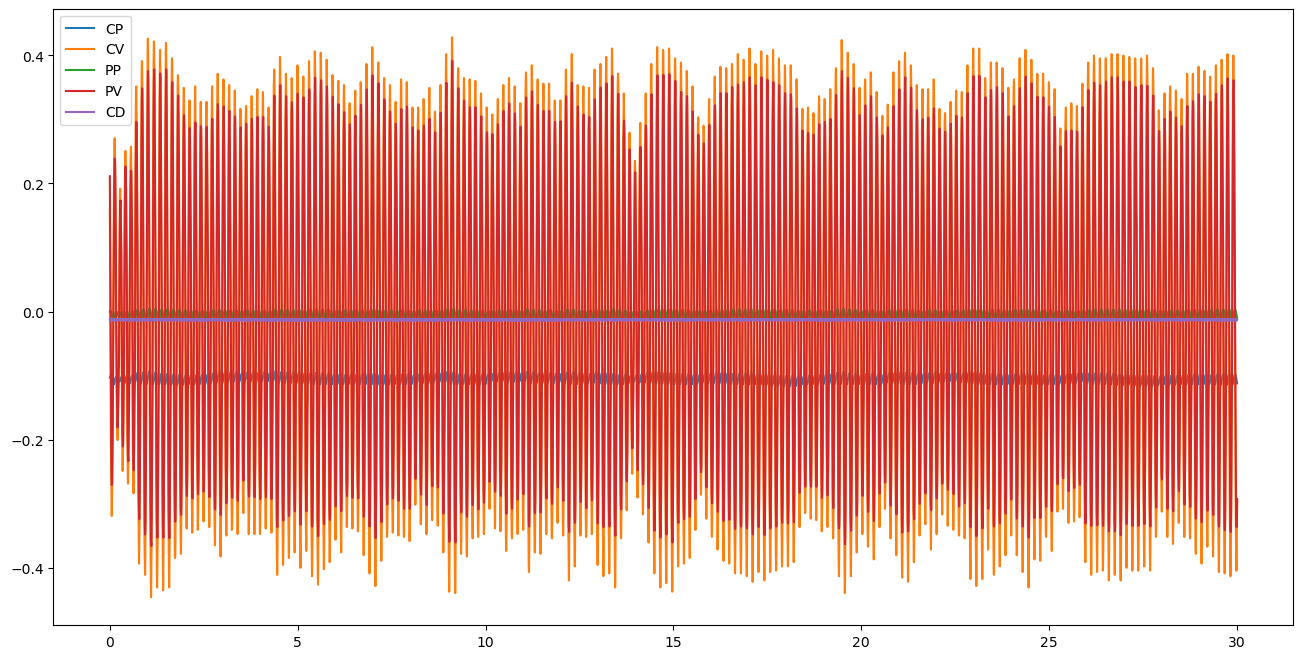

In [26]:
############################## LOAD DATA  #######################################

xdata, xdem, tdata = loadlogdata(23,Sp)
# in the previous line xdem is the external input into the system.

plt.plot(tdata,xdata)
plt.legend(['CP','CV','PP','PV','CD']);

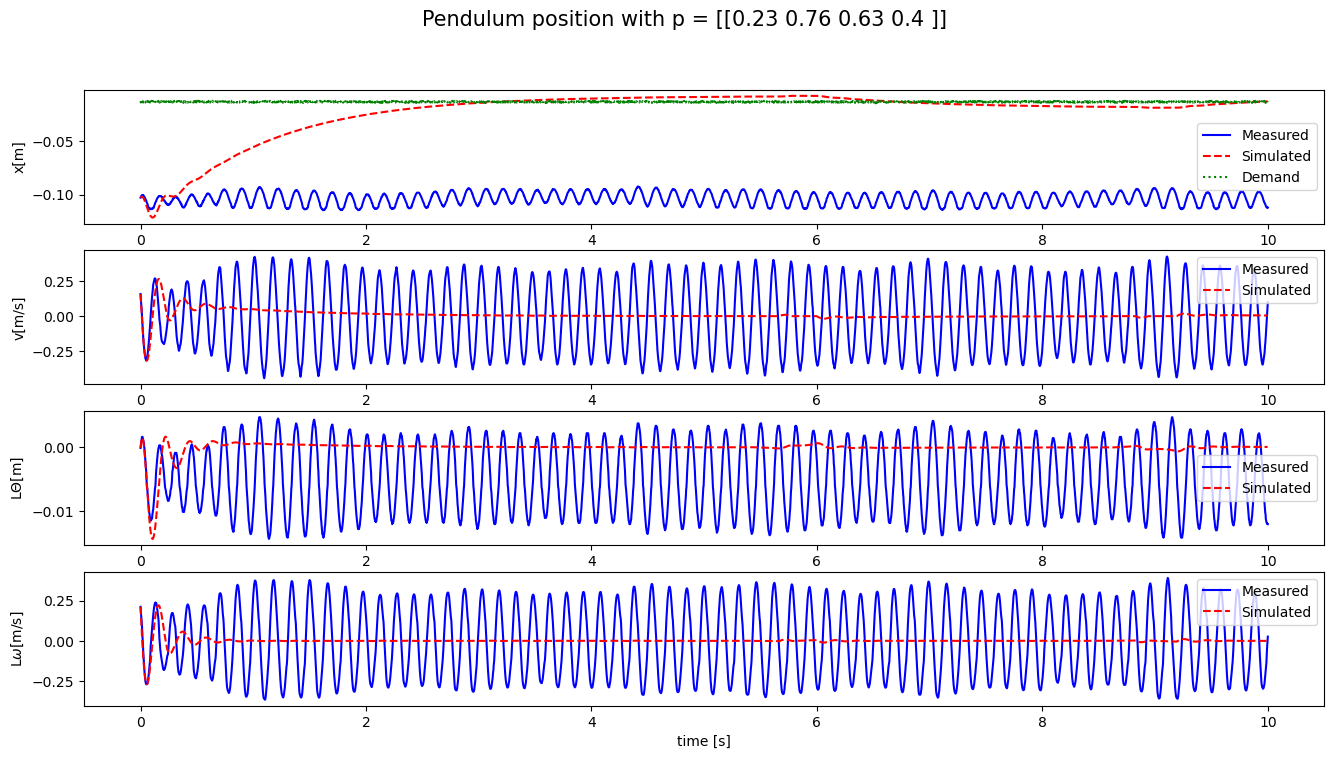

In [27]:
t0 = 0; tf = 10 # define the simlation time to be considered

# Set up the initial conditions and time index for the simulation, this uses the recorded data

tsim = np.arange(t0,tf,h_sim)
x0=scipy.interpolate.interp1d(tdata,xdata[:,:4].T)(t0)

x_sim = solver_pendulum(x0,tsim,tdata,xdem,P)

plot_function_pendulum(t0,tf,tdata,xdata,tsim,x_sim,P)

# Comment and discuss here section 4.4) after changing $p_2$

Value of $p_2$ for at the onset of instability: <br>

Describe and explain the beahviour when $p_3=p_4=0$
...

## 4.5) No pendulum feedback
If the design of 4.3) is implemented except with $p_3 = p_4 = 0$ what would happen, and why?

In [28]:
P = np.array([[0.23, 0.5, 0.0, 0.0]])
print("P:", P)
print(np.linalg.eig(Ap-B@P@Cp)[0]) 
# Note that the [0] is there to ignore the second output of eig

P: [[0.23 0.5  0.   0.  ]]
[56.76028402  8.63486053 -1.25161228 -9.08180388]


# Comment and discuss here section 4.5


If p3 and p4 are set to 0, this gives up pendulum feedback, meaning that in the characteristic equation for the feedback of the inverted pendulum model, the coefficient for s^2 will be negative, since k1 < 0, k3 = 0. This will cause the system to oscillate unstably to infinity.

# <center> Feedback to the student <center>

## Content

### Completeness, quantity of content: Very good | Good | Needs improvement
Has the report covered all aspects of the lab? Has the analysis been carried out thoroughly?

### Correctness, quality of content: Very good | Good | Needs improvement
Is the data correct? Is the analysis of the data correct? Are the conclusions correct?

### Depth of understanding, quality of discussion: Very good | Good | Needs improvement
Does the report show a good technical understanding? Have all the relevant conclusions been drawn?

### Comments

...

## Presentation

### Attention to detail, typesetting and typographical errors: Very good | Good | Needs improvement
Is the report free of typographical errors? Are the figures/tables/references presented professionally?

### Comments

...

# Raw report Mark:
The weighting of comments is not intended to be equal, and the relative importance of criteria may vary between modules. A good report  should  attract 4 marks.

# Penalty for lateness: 
1 mark / week or part week.Please refer to the online information regarding our extension policy.

Marker: <br>
Date: <br>